In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("weight-height.csv")
print(df.head(10))

  Gender     Height      Weight
0   Male  73.847017  241.893563
1   Male  68.781904  162.310473
2   Male  74.110105  212.740856
3   Male  71.730978  220.042470
4   Male  69.881796  206.349801
5   Male  67.253016  152.212156
6   Male  68.785081  183.927889
7   Male  68.348516  167.971110
8   Male  67.018950  175.929440
9   Male  63.456494  156.399676


In [4]:
print(df.isnull().sum())

Gender    0
Height    0
Weight    0
dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


In [7]:
print(df.duplicated().sum())

0


In [9]:
df['Height'] = df['Height'].fillna(df['Height'].mean())
df['Weight'] = df['Weight'].fillna(df['Weight'].mean())

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df['Gender'] = df['Gender'].str.strip().str.lower()

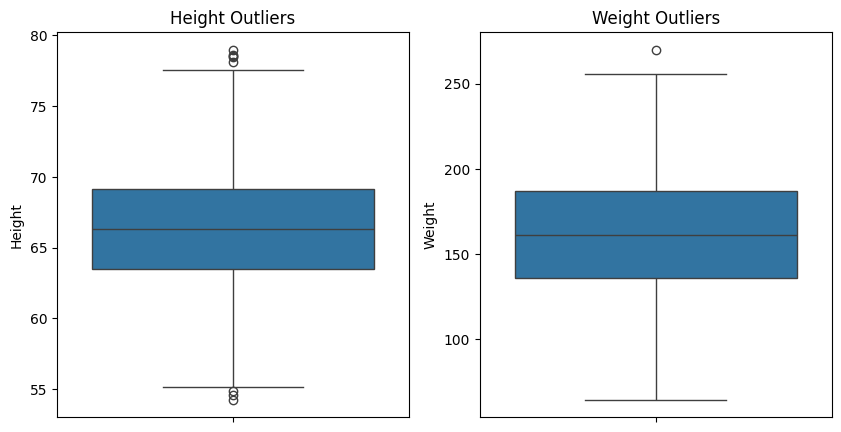

In [12]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.boxplot(y=df['Height'])
plt.title("Height Outliers")

plt.subplot(1,2,2)
sns.boxplot(y=df['Weight'])
plt.title("Weight Outliers")

plt.show()

In [13]:
Q1 = df['Weight'].quantile(0.25)
Q3 = df['Weight'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

58.79084096072856 264.19673521345646


In [14]:
df = df[(df['Weight'] >= lower) & (df['Weight'] <= upper)]

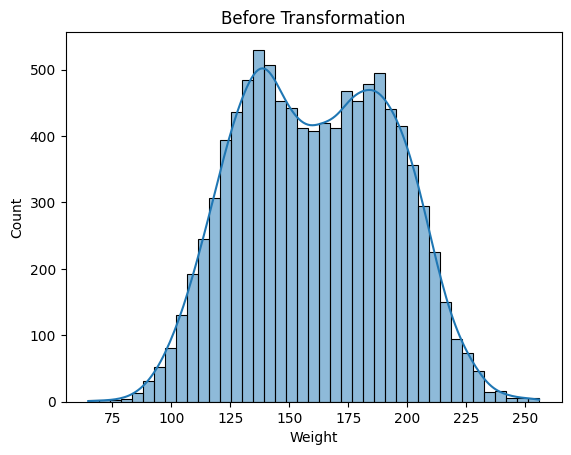

In [15]:
sns.histplot(df['Weight'], kde=True)
plt.title("Before Transformation")
plt.show()

In [16]:
df['Weight_log'] = np.log(df['Weight'])

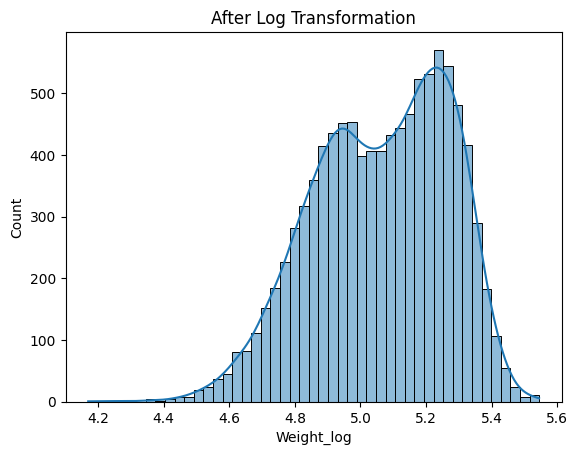

In [17]:
sns.histplot(df['Weight_log'], kde=True)
plt.title("After Log Transformation")
plt.show()

In [18]:
print(df.head())

  Gender     Height      Weight  Weight_log
0   male  73.847017  241.893563    5.488498
1   male  68.781904  162.310473    5.089511
2   male  74.110105  212.740856    5.360075
3   male  71.730978  220.042470    5.393821
4   male  69.881796  206.349801    5.329573


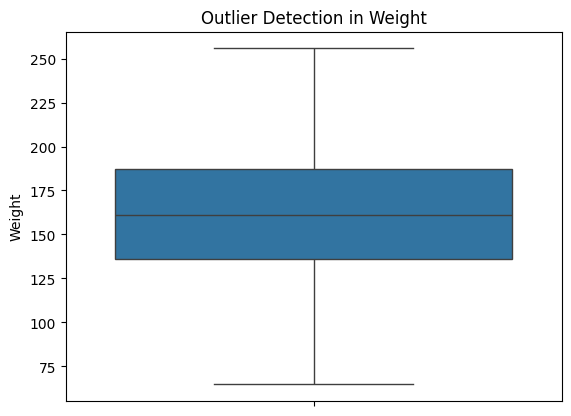

In [19]:
sns.boxplot(y=df['Weight'])
plt.title("Outlier Detection in Weight")
plt.show()